# Лабораторная работа №2. Метод ломаных

## 1. Постановка задачи

Метод ломаных предназначен для поиска глобального экстремума липшицевой функции на заданном отрезке.

В данной работе необходимо найти глобальный минимум функции

$$
W(x)=x\sin(3x)+0.2x^2
$$

на отрезке

$$
x\in[-2,3].
$$

Результатом работы алгоритма должны быть приближённое значение аргумента минимума, значение функции в найденной точке, количество итераций и время вычисления.

## 2. Исходная функция и параметры

Для выбранной функции используются следующие параметры:

$$
a=-2,\qquad b=3,
$$

$$
L=8,
$$

$$
\varepsilon=0.01.
$$

Значение $L$ является константой Липшица, а $\varepsilon$ задаёт точность остановки алгоритма.

In [2]:
%pip install matplotlib numpy

  Using cached matplotlib-3.11.2-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.1-cp313-cp313-win_amd64.whl.metadata (132 kB)
  Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached matplotlib-3.11.2-cp313-cp313-win_amd64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp313-cp313-win_amd64.whl (234 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.66.1-cp313-cp313-win_amd64.whl (2.5 MB)
Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl (70 kB)
Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.3-py3-none-any.whl (126 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt


_ALLOWED_MATH = {
    "sin": math.sin,
    "cos": math.cos,
    "tan": math.tan,
    "exp": math.exp,
    "log": math.log,
    "sqrt": math.sqrt,
    "pi": math.pi,
    "e": math.e,
    "abs": abs,
}

def make_function(expression):
    # Создаём функцию из строки для учебного ввода
    def func(x):
        local_env = dict(_ALLOWED_MATH)
        local_env["x"] = x
        return float(eval(expression, {"__builtins__": {}}, local_env))
    return func

In [ ]:
# Ввод исходных данных
FUNCTION_EXPRESSION = input("Введите функцию W(x)")

a = float(input("Введите левую границу a: "))
b = float(input("Введите правую границу b: "))
L = float(input("Введите константу Липшица L: "))
eps = float(input("Введите точность eps: "))

if a >= b:
    raise ValueError("Левая граница a должна быть меньше b.")

if L <= 0:
    raise ValueError("Константа Липшица L должна быть положительной.")

if eps <= 0:
    raise ValueError("Точность eps должна быть положительной.")

W = make_function(FUNCTION_EXPRESSION)

print("\nИсходные данные:")
print(f"W(x) = {FUNCTION_EXPRESSION}")
print(f"Отрезок: [{a}, {b}]")
print(f"L = {L}")
print(f"eps = {eps}")


Исходные данные:
W(x) = x * sin(3 * x) + 0.2 * x**2
Отрезок: [-2.0, 3.0]
L = 8.0
eps = 0.01


## 4. Вычисление точек пересечения

Координата нижней вершины:

$$
u_{\text{cross}}
=
\frac{W(u_q)-W(u_v)}{2L}
+
\frac{u_q+u_v}{2}.
$$

Значение миноранты:

$$
p(u_{\text{cross}})
=
W(u_q)-L(u_{\text{cross}}-u_q).
$$

In [35]:

def intersection(u_left, w_left, u_right, w_right, L):
    # Вычисляем нижнюю вершину между двумя соседними верхними вершинами
    x_cross = (w_left - w_right) / (2 * L) + (u_left + u_right) / 2

    # Вычисляем значение миноранты в точке пересечения
    p_cross = w_left - L * (x_cross - u_left)

    return x_cross, p_cross


## 5. Построение нижних вершин

Для каждой пары соседних верхних вершин вычисляется нижняя вершина.

Следующая проба выполняется в точке с минимальным значением p(x).


In [36]:

def build_lower_vertices(upper_vertices, L):
    # Формируем все нижние вершины текущей ломаной
    lower_vertices = []

    for i in range(len(upper_vertices) - 1):
        u_left, w_left = upper_vertices[i]
        u_right, w_right = upper_vertices[i + 1]

        x_cross, p_cross = intersection(
            u_left,
            w_left,
            u_right,
            w_right,
            L
        )

        lower_vertices.append({
            "x": x_cross,
            "p": p_cross,
            "left": u_left,
            "right": u_right
        })

    return lower_vertices


## 6. Алгоритм метода

На каждой итерации выбирается минимальная нижняя вершина, вычисляется значение функции и проверяется условие

$$
\delta=W(u_n)-p(u_n).
$$

Если

$$
\delta<\varepsilon,
$$

алгоритм завершается.

## 7. Реализация метода


In [37]:

def piyavsky_method(func, a, b, L, eps, max_iterations=1000, verbose=True):
    start_time = time.perf_counter()

    # Первые пробы выполняются на концах отрезка
    upper_vertices = [
        (a, func(a)),
        (b, func(b))
    ]

    history = []
    iteration = 0

    while iteration < max_iterations:
        iteration += 1

        # Строим нижние вершины текущей ломаной
        lower_vertices = build_lower_vertices(upper_vertices, L)

        # Выбираем самую низкую нижнюю вершину
        # При равенстве min оставляет первую найденную точку
        best_lower = min(lower_vertices, key=lambda point: point["p"])

        u_new = best_lower["x"]
        p_new = best_lower["p"]

        # Вычисляем исходную функцию только в выбранной точке
        w_new = func(u_new)

        # Вычисляем разрыв между функцией и минорантой
        delta = w_new - p_new

        history.append({
            "iteration": iteration,
            "u": u_new,
            "W": w_new,
            "p": p_new,
            "delta": delta,
            "upper_vertices": upper_vertices.copy(),
            "lower_vertices": lower_vertices.copy()
        })

        if verbose:
            print(
                f"Итерация {iteration}: "
                f"u = {u_new:.6f}, "
                f"W(u) = {w_new:.6f}, "
                f"p(u) = {p_new:.6f}, "
                f"δ = {delta:.6f}"
            )

        # Критерий остановки
        if delta < eps:
            elapsed_time = time.perf_counter() - start_time

            # Находим лучшую пробу среди всех вычисленных точек
            best_point = min(history, key=lambda item: item["W"])

            # Добавляем точку остановки в финальный набор верхних вершин
            final_upper_vertices = upper_vertices.copy()
            final_upper_vertices.append((u_new, w_new))
            final_upper_vertices.sort(key=lambda point: point[0])

            return {
                "x_min": u_new,
                "f_min": w_new,
                "best_x": best_point["u"],
                "best_f": best_point["W"],
                "iterations": iteration,
                "time": elapsed_time,
                "upper_vertices": final_upper_vertices,
                "history": history
            }

        # Нижняя вершина становится новой верхней вершиной
        upper_vertices.append((u_new, w_new))
        upper_vertices.sort(key=lambda point: point[0])

    elapsed_time = time.perf_counter() - start_time

    raise RuntimeError(
        f"Метод не сошёлся за {max_iterations} итераций. "
        f"Время: {elapsed_time:.6f} сек."
    )


## 8. Запуск алгоритма

Выполняем расчёт для выбранной функции и заданных параметров.

In [38]:

result = piyavsky_method(
    func=W,
    a=a,
    b=b,
    L=L,
    eps=eps,
    max_iterations=max_iterations
)


print("\nРезультат:")
print(f"Точка остановки: x* ≈ {result['x_min']:.6f}")
print(f"W(x*) ≈ {result['f_min']:.6f}")

print("\nЛучшая найденная проба:")
print(f"x_best ≈ {result['best_x']:.6f}")
print(f"W(x_best) ≈ {result['best_f']:.6f}")

print(f"\nКоличество итераций: {result['iterations']}")
print(f"Время: {result['time']:.6f} сек.")


Итерация 1: u = 0.325301, W(u) = 0.290581, p(u) = -18.361238, δ = 18.651819
Итерация 2: u = 1.491040, W(u) = -1.003922, p(u) = -9.035328, δ = 8.031407
Итерация 3: u = -0.840438, W(u) = 0.629782, p(u) = -9.035328, δ = 9.665110
Итерация 4: u = 1.993002, W(u) = 0.197490, p(u) = -5.019625, δ = 5.217115
Итерация 5: u = 0.989077, W(u) = 0.367240, p(u) = -5.019625, δ = 5.386865
Итерация 6: u = -1.444507, W(u) = -0.924749, p(u) = -4.202773, δ = 3.278025
Итерация 7: u = -0.236368, W(u) = 0.165086, p(u) = -4.202773, δ = 4.367860
Итерация 8: u = -1.649384, W(u) = -1.059663, p(u) = -2.563761, δ = 1.504098
Итерация 9: u = -1.239631, W(u) = -0.369208, p(u) = -2.563761, δ = 2.194553
Итерация 10: u = 1.666933, W(u) = -1.042351, p(u) = -2.411068, δ = 1.368716
Итерация 11: u = 2.319072, W(u) = 2.523046, p(u) = -2.411068, δ = 4.934114
Итерация 12: u = 1.325756, W(u) = -0.631852, p(u) = -2.326192, δ = 1.694340
Итерация 13: u = 0.652398, W(u) = 0.689423, p(u) = -2.326192, δ = 3.015615
Итерация 14: u = -0.5

## 9. Визуализация

Строятся график функции, итоговая ломаная, верхние вершины и найденные точки.

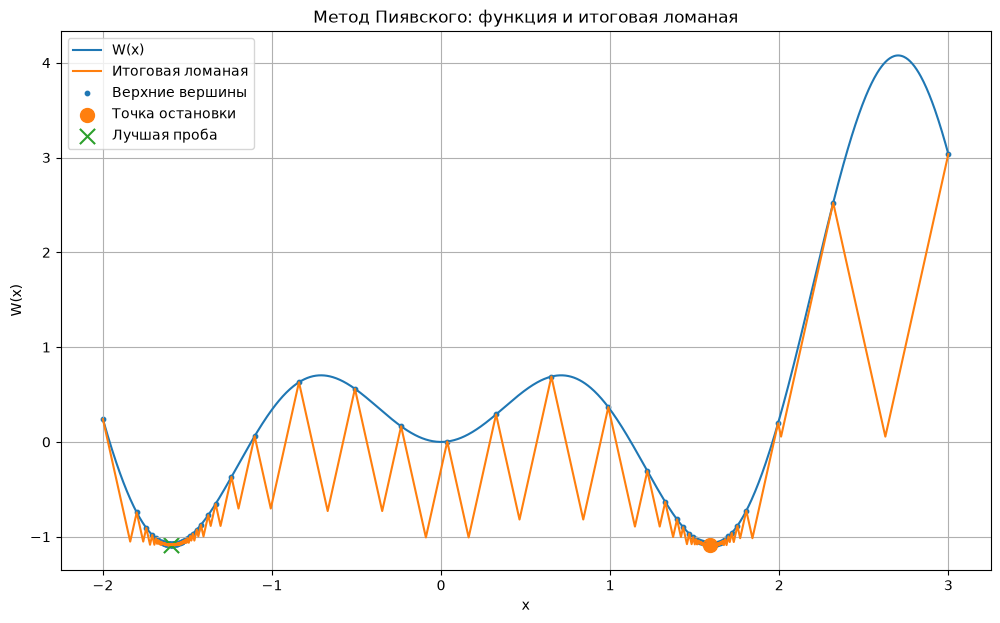

In [39]:

def build_broken_line(upper_vertices, L):
    # Формируем координаты итоговой ломаной
    broken_line = []

    for i in range(len(upper_vertices) - 1):
        u_left, w_left = upper_vertices[i]
        u_right, w_right = upper_vertices[i + 1]

        x_cross, p_cross = intersection(
            u_left,
            w_left,
            u_right,
            w_right,
            L
        )

        if i == 0:
            broken_line.append((u_left, w_left))

        broken_line.append((x_cross, p_cross))
        broken_line.append((u_right, w_right))

    return broken_line


def plot_result(func, a, b, L, result):
    # Сетка используется только для отображения исходной функции
    x_values = np.linspace(a, b, 1200)
    y_values = [func(x) for x in x_values]

    upper_vertices = result["upper_vertices"]
    broken_line = build_broken_line(upper_vertices, L)

    broken_x = [point[0] for point in broken_line]
    broken_y = [point[1] for point in broken_line]

    upper_x = [point[0] for point in upper_vertices]
    upper_y = [point[1] for point in upper_vertices]

    plt.figure(figsize=(12, 7))

    plt.plot(x_values, y_values, label="W(x)")
    plt.plot(broken_x, broken_y, label="Итоговая ломаная")

    plt.scatter(
        upper_x,
        upper_y,
        s=10,
        label="Верхние вершины"
    )

    plt.scatter(
        result["x_min"],
        result["f_min"],
        s=100,
        marker="o",
        label="Точка остановки"
    )

    plt.scatter(
        result["best_x"],
        result["best_f"],
        s=120,
        marker="x",
        label="Лучшая проба"
    )

    plt.xlabel("x")
    plt.ylabel("W(x)")
    plt.title("Метод Пиявского: функция и итоговая ломаная")
    plt.grid(True)
    plt.legend()
    plt.show()


plot_result(
    func=W,
    a=a,
    b=b,
    L=L,
    result=result
)


## 10. Дополнительная проверка

Для проверки универсальности реализации используется вторая функция:

$$
W_2(x)=x^2(x^2-1)^2
$$

на отрезке

$$
[-1.2,1.2].
$$

Для неё выбраны параметры:

$$
L=4,\qquad \varepsilon=0.01.
$$

Функция имеет несколько локальных экстремумов и отличается по структуре от основной тестовой функции.

In [40]:
FUNCTION_EXPRESSION_2 = "x**2 * (x**2 - 1)**2"

W2 = make_function(FUNCTION_EXPRESSION_2)

a2 = -1.2
b2 = 1.2
L2 = 4.0
eps2 = 0.01

result2 = piyavsky_method(
    func=W2,
    a=a2,
    b=b2,
    L=L2,
    eps=eps2,
    max_iterations=1000,
    verbose=False
)

print("Дополнительная проверка:")
print(f"Функция: {FUNCTION_EXPRESSION_2}")

print(f"\nТочка остановки: x* ≈ {result2['x_min']:.6f}")
print(f"W2(x*) ≈ {result2['f_min']:.6f}")

print("\nЛучшая найденная проба:")
print(f"x_best ≈ {result2['best_x']:.6f}")
print(f"W2(x_best) ≈ {result2['best_f']:.6f}")

print(f"\nКоличество итераций: {result2['iterations']}")
print(f"Время: {result2['time']:.6f} сек.")

Дополнительная проверка:
Функция: x**2 * (x**2 - 1)**2

Точка остановки: x* ≈ -0.005505
W2(x*) ≈ 0.000030

Лучшая найденная проба:
x_best ≈ 0.000000
W2(x_best) ≈ 0.000000

Количество итераций: 188
Время: 0.025715 сек.


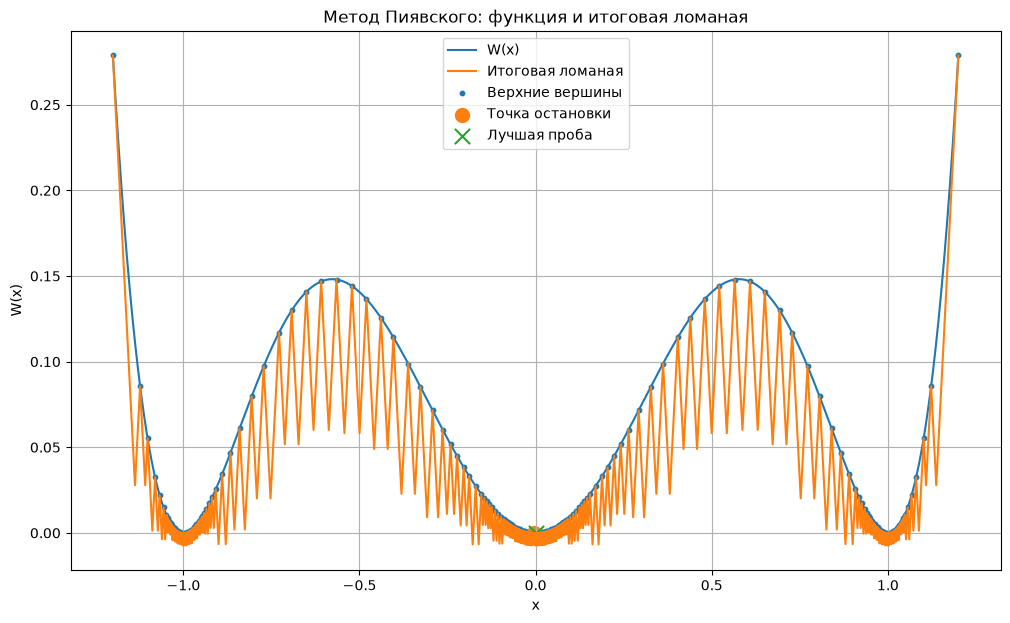

In [15]:
plot_result(
    func=W2,
    a=a2,
    b=b2,
    L=L2,
    result=result2
)